# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



# LEARNING OBJECTIVES

After this lab session, students will understand and be able to implement the following:

---

## 🧠 Conceptual Knowledge

- The concept of **word representation**
- The difference between **one-hot encoding** and **word embeddings**
- The concept of a **context window**
- How the **Skip-gram** model learns word embeddings
- How the **CBOW (Continuous Bag of Words)** model learns word embeddings
- The key differences between the **Skip-gram** and **CBOW** models

---

## 💻 Practical Skills

Students will be able to:

- Build a **vocabulary** from a corpus
- Generate **training data using a context window**
- Implement the **Skip-gram model using PyTorch**
- Implement the **CBOW model using PyTorch**
- Analyze and interpret **word embedding vectors**

# SHORT THEORY

---

## Limitation of One-Hot Encoding

**Example**

| Word | One-hot vector |
|-----|-----|
| king | [1, 0, 0, 0] |
| queen | [0, 1, 0, 0] |

⚠️ **Problems with one-hot encoding**

- Vectors are **very sparse**
- They **do not capture semantic meaning**
- It is difficult to measure **word similarity**

**Example**
$$similarity(king, queen) = 0$$

> ❌ This is incorrect from a semantic perspective because **"king" and "queen" are clearly related**.

---

## Word Embedding

Word embeddings represent words using **dense vectors**.

Example:

king → [0.23, -0.41, 0.89]

queen → [0.25, -0.39, 0.87]


✅ **Advantages**

- Dense vector representation  
- Capture **semantic relationships between words**  
- Allow similarity computation using **cosine similarity**

Example:

$$similarity(king, queen) \approx high$$

---

## Context Window

A **context window** refers to the number of surrounding words used to understand a target word.

**Example sentence**: I love natural language processing


Window size = **2**

Context of **"natural"**: love, language


> 💡 The model learns word meaning from **neighboring words**.

---

## Skip-gram

🎯 **Goal**

Predict **context words** from a **center word**.

Example:

Center word: natural

Context words: love, language

Training pairs:
- (natural → love)
- (natural → language)


> The model learns embeddings by predicting surrounding words.

---

## CBOW (Continuous Bag of Words)

CBOW works in the **opposite direction of Skip-gram**.

🎯 **Goal**

Predict the **center word** from the **context words**.

Example:

Context words: love language


Predict: natural


---

## Skip-gram vs CBOW

| Model | Input | Output |
|------|------|------|
| Skip-gram | Center word | Context words |
| CBOW | Context words | Center word |

📊 **Typical characteristics**

- **CBOW**
  - Faster to train
  - Works well with large datasets

- **Skip-gram**
  - Better for **rare words**
  - Learns more detailed word representations






# Code Sample

## Corpus

In [ ]:
corpus = [
    "I love natural language processing",
    "I love deep learning",
    "natural language processing is fun",
    "deep learning is powerful",
    "machine learning is interesting",
    "I enjoy studying machine learning",
    "deep neural networks are powerful",
    "natural language processing is important",
    "I love studying artificial intelligence",
    "artificial intelligence is the future",
    "deep learning models are effective",
    "machine learning models are useful",
    "natural language processing helps understanding text",
    "deep learning is used in computer vision",
    "I enjoy learning about neural networks",
    "AI is transforming the world",
    "data science and machine learning are related",
    "neural networks learn representations",
    "deep learning requires large data",
    "natural language processing is a part of AI"
]

## One-hot encoding

In [ ]:
import numpy as np

vocab = ["I", "love", "NLP"]
word_to_idx = {w:i for i,w in enumerate(vocab)}

def one_hot(word):
    vec = np.zeros(len(vocab))
    vec[word_to_idx[word]] = 1
    return vec

print(one_hot("love"))

# output [0,1,0]

[0. 1. 0.]


## Tokenization

In [ ]:
tokens = [sentence.lower().split() for sentence in corpus]

print(tokens)

[['i', 'love', 'natural', 'language', 'processing'], ['i', 'love', 'deep', 'learning'], ['natural', 'language', 'processing', 'is', 'fun'], ['deep', 'learning', 'is', 'powerful'], ['machine', 'learning', 'is', 'interesting'], ['i', 'enjoy', 'studying', 'machine', 'learning'], ['deep', 'neural', 'networks', 'are', 'powerful'], ['natural', 'language', 'processing', 'is', 'important'], ['i', 'love', 'studying', 'artificial', 'intelligence'], ['artificial', 'intelligence', 'is', 'the', 'future'], ['deep', 'learning', 'models', 'are', 'effective'], ['machine', 'learning', 'models', 'are', 'useful'], ['natural', 'language', 'processing', 'helps', 'understanding', 'text'], ['deep', 'learning', 'is', 'used', 'in', 'computer', 'vision'], ['i', 'enjoy', 'learning', 'about', 'neural', 'networks'], ['ai', 'is', 'transforming', 'the', 'world'], ['data', 'science', 'and', 'machine', 'learning', 'are', 'related'], ['neural', 'networks', 'learn', 'representations'], ['deep', 'learning', 'requires', 'l

## Vocabulary

In [ ]:
vocab = set()

for sentence in tokens:
    vocab.update(sentence)

vocab = list(vocab)

## Word → Index

In [ ]:
word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}

vocab_size = len(vocab)

print(vocab_size)

47


## BUILD TRAINING DATA

Context Window

Window size = 2

### Skip-gram training pairs
sentence: I love NLP

(love → I)

(love → NLP)

In [ ]:
window_size = 2
skipgram_data = []

for sentence in tokens:
    for i, word in enumerate(sentence):
        center = word_to_idx[word]

        for j in range(-window_size, window_size+1):
            if j == 0:
                continue
            if i+j >=0 and i+j < len(sentence):
                context = word_to_idx[sentence[i+j]]
                skipgram_data.append((center, context))

print(skipgram_data[:10])

[(29, 19), (29, 8), (19, 29), (19, 8), (19, 13), (8, 29), (8, 19), (8, 13), (8, 12), (13, 19)]


### CBOW training samples

Input: context words

Output: center word

In [ ]:
cbow_data = []

for sentence in tokens:
    for i in range(window_size, len(sentence)-window_size):

        context = []
        for j in range(-window_size, window_size+1):
            if j != 0:
                context.append(word_to_idx[sentence[i+j]])

        target = word_to_idx[sentence[i]]

        cbow_data.append((context, target))

print(cbow_data[:5])

[([29, 19, 13, 12], 8), ([8, 13, 11, 30], 12), ([29, 45, 14, 46], 18), ([7, 10, 0, 44], 36), ([8, 13, 11, 15], 12)]


## IMPLEMENT (Pytorch)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def plot_embeddings(embeddings):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1])

    for i, word in enumerate(idx_to_word.values()):
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title("Word Embeddings Visualization (PCA)")
    plt.show()



def show_vector(word,embeddings):
    idx = word_to_idx[word]
    print(f"\nVector của '{word}':\n")
    print(embeddings[idx])

### SKIP-GRAM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


class SkipGram(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):

        embed = self.embedding(x)
        out = self.linear(embed)

        return out

In [ ]:
embed_dim = 10

model = SkipGram(vocab_size, embed_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 200

for epoch in range(epochs):

    total_loss = 0

    for center, context in skipgram_data:

        center = torch.tensor([center])
        context = torch.tensor([context])

        output = model(center)

        loss = criterion(output, context)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 1150.6895371079445
Epoch: 20 Loss: 623.0309129953384
Epoch: 40 Loss: 611.5593199431896
Epoch: 60 Loss: 608.1137123703957
Epoch: 80 Loss: 605.2304582297802
Epoch: 100 Loss: 603.5382295250893
Epoch: 120 Loss: 601.7870008349419
Epoch: 140 Loss: 600.5512769818306
Epoch: 160 Loss: 599.7766330242157
Epoch: 180 Loss: 599.055689573288


In [ ]:
embeddings = model.embedding.weight.data.numpy()

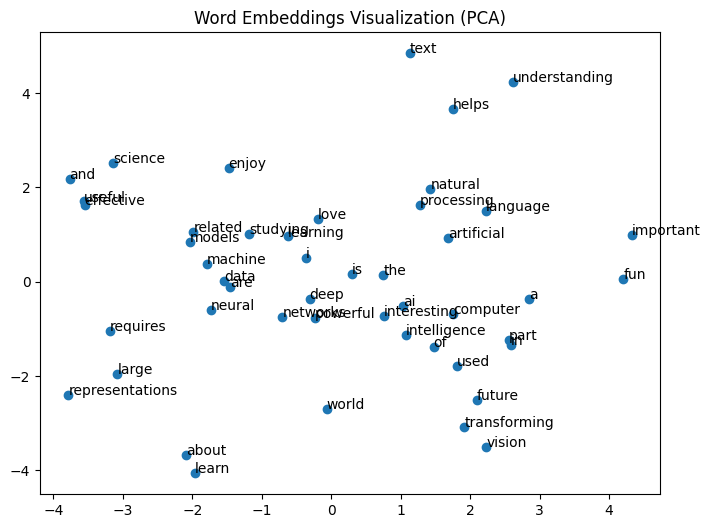

In [ ]:
plot_embeddings(embeddings)

In [ ]:
show_vector("learning", embeddings)


Vector của 'learning':

[ 0.9173324   0.8928414   0.6892556  -0.74493515  0.03402014 -0.39248526
  0.1647922  -0.07352614 -0.48838663 -0.20894384]


### CBOW

In [ ]:
class CBOW(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, context):

        embeds = self.embedding(context)

        mean_embed = embeds.mean(dim=1)

        out = self.linear(mean_embed)

        return out

In [ ]:
model = CBOW(vocab_size, embed_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 200

for epoch in range(epochs):

    total_loss = 0

    for context, target in cbow_data:

        context = torch.tensor([context])
        target = torch.tensor([target])

        output = model(context)

        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 95.77844309806824
Epoch: 20 Loss: 3.8391496427357197
Epoch: 40 Loss: 0.6143502709455788
Epoch: 60 Loss: 0.23680382315069437
Epoch: 80 Loss: 0.1210735755157657
Epoch: 100 Loss: 0.07089977248688228
Epoch: 120 Loss: 0.044898040301632136
Epoch: 140 Loss: 0.029885841242503375
Epoch: 160 Loss: 0.02057653920201119
Epoch: 180 Loss: 0.014510219749354292


## Simple Analysis

In [ ]:
embeddings = model.embedding.weight.data

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

word = "learning"

word_vec = embeddings[word_to_idx[word]].unsqueeze(0)

similarities = cosine_similarity(word_vec, embeddings)

for i in similarities.argsort()[0][-5:]:
    print(idx_to_word[i])

artificial
powerful
useful
computer
learning


In [ ]:
show_vector("learning",embeddings)


Vector của 'learning':

tensor([-2.5398,  3.0028,  1.1685, -0.4555,  1.4070, -0.2210,  0.9930,  3.0689,
        -0.4658, -3.3832])


 # Homewwork

## 💬 Discussion Questions

1️⃣ Why is one-hot encoding inefficient?

2️⃣ Why can embedding vectors capture semantic meaning?

3️⃣ What is the role of the context window?

4️⃣ Why does the Skip-gram model perform well on rare words?

5️⃣ Why is CBOW faster to train?

In [ ]:
!rm -rf ~/.cache/huggingface
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G  4.0K  5.8G   1% /dev/shm
/dev/root       2.0G  1.2G  748M  63% /usr/sbin/docker-init
tmpfs           6.4G  168K  6.4G   1% /var/colab
/dev/sda1       114G  109G  5.3G  96% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


In [ ]:
from datasets import load_dataset

dataset = load_dataset("VTSNLP/vietnamese_curated_dataset",split="train",streaming = True)
print(dataset)

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

IterableDataset({
    features: ['text', 'id', 'domain'],
    num_shards: 132
})


In [ ]:
dataset = dataset.take(10000)

In [ ]:
for idx,row in enumerate(dataset):
    print(f"sentence: {idx} ==============================================")
    print(row["text"], row["id"], "\n")
    if idx == 5:
      break

sentence: 0 ==============================================
Internet Society hay ISOC là một tổ chức quốc tế hoạt động phi lợi nhuận, phi chính phủ và bao gồm các thành viên có trình độ chuyên ngành. Tổ chức này chú trọng đến: tiêu chuẩn, giáo dục và các vấn đề về chính sách. Với trên 145 tổ chức thành viên và 65.000 thành viên cá nhân, ISOC bao gồm những con người cụ thể trong cộng đồng Internet. Mọi chi tiết có thể tìm thấy tại website của ISOC.

Internet Society nằm ở gần thủ đô Washington, DC, Hoa Kỳ và Geneva, Thụy Sĩ. Số hội viên của nó bao gồm hơn 145 tổ chức thành viên và hơn 65.000 cá nhân. Thành viên còn có thể tự lập một chi nhánh của tổ chức tùy theo vị trí hoặc sở thích. Hiện nay tổ chức có tới 90 chi nhánh trên toàn thế giới.

Nhiệm vụ và mục đích hoạt động
Bảo đảm, cổ vũ cho sự phát triển, mở rộng và sử dụng Internet được thuận lợi nhất cho mọi người trên toàn thế giới.

Xem thêm
Lịch sử Internet

Tham khảo

Liên kết ngoài
 
 
 ISOC Việt Nam
 IETF and the Internet Society

## 🧪 Experiments & Exercises

1️⃣ Implement Skip-gram using NumPy

    ⚠️ Do not use deep learning libraries (e.g., PyTorch, TensorFlow)

2️⃣ Train the model on a larger corpus
"Word Embedding với OSCAR Vietnamese Corpus"

```python
from datasets import load_dataset

dataset = load_dataset("VTSNLP/vietnamese_curated_dataset")
```

PART 1 — DATA PREPROCESSING (REQUIRED)

 ✅ Requirements

- Extract text
- Clean the data:
    - Convert to lowercase

    - Remove special characters

    - Remove numbers

- Tokenization

PART 2 — BUILD VOCABULARY & TRAINING DATA

✅ Requirements

- Build a vocabulary:
    - Limit size: max_vocab = 10000

    - Remove words that appear less than 5 times

- Construct:
    - Skip-gram pairs

    - CBOW samples

- Experiments: Change window_size = 2 / 3 / 5

📊 Questions

- How does a larger context window affect embeddings?
- How does a larger vocabulary impact training speed?

PART 3 — TRAIN SKIP-GRAM

✅ Requirements

- Implement Skip-gram using PyTorch
- Train on the dataset
- Change:
```python
embedding_dim = 50 / 100 / 200
```
📊 Record

- Training loss per epoch

- Training time

PART 4 — TRAIN CBOW

✅ Requirements
- Implement CBOW
- Compare with Skip-gram

📊 Comparison
Metric: Loss, Time, Stability (Cbow and skip-gram)


PART 5 — WORD SIMILARITY (IMPORTANT)

✅ Requirements

Implement the function:
```pyhton
def most_similar(word, top_k=5):
    ...

```

🧪 Test with words:

- học

- giáo_viên

- công_nghệ

- việt_nam

🎯 Analysis

- Are the returned words semantically meaningful?

- Is there any noise?


PART 6 — EMBEDDING ANALYSIS

✅ Requirements
- Use PCA or t-SNE: Visualize ~100 frequent words

🎯 Questions

- Do words with similar meanings form clusters?

- Are there any outliers?


PART 7 — SKIP-GRAM vs CBOW COMPARISON

Write a short report
- Include:
  - Experimental Results: Loss, Training time, Word similarity quality
  - Comments on the model eperimenting

